In [1]:
from rdkit import Chem
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ShuffleSplit, GridSearchCV, cross_val_score, cross_validate
import os
import glob
from scipy.stats import norm
import math
import random

In [2]:
from sklearn.neural_network import MLPRegressor
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error 


T_0 = pd.read_excel('STING合集0和1.xlsx')
T=np.array(T_0)
#from sklearn import preprocessing  
#min_max_scaler = preprocessing.MinMaxScaler() 
#T=T_minMax = min_max_scaler.fit_transform(T)
#T=T.ravel()

print(T)  
print(len(T))

[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
1014


In [3]:
#读入特征    1000种描述符数据 
X=pd.read_excel('CDK+CDK extended+substructure.xlsx')
X=np.array(X) 
#min_max_scaler = preprocessing.MinMaxScaler() 
#X=X_minMax = min_max_scaler.fit_transform(X)
print(X)
print(len(X[0]))
print(len(X))

[[0 1 1 ... 0 0 1]
 [1 0 1 ... 0 0 1]
 [1 0 1 ... 0 0 1]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]
 [1 1 1 ... 0 0 1]]
2355
1014


In [4]:
from sklearn.model_selection import train_test_split
X_train,  X_test,  T_train,  T_test  =  train_test_split(X,T,test_size=0.200,random_state=69)

In [5]:
from sklearn.metrics import accuracy_score,precision_score,f1_score
import lightgbm as lgbm
clf=lgbm.LGBMClassifier(boosting_type='gbdt',colsample_bytree=0.8,feature_fraction=0.8,bagging_fraction=0.1,num_leaves=10,min_child_samples=60,max_depth=-1,
                        learning_rate=0.01,n_estimators=300, n_jobs=1)
clf.fit(X_train,T_train)


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.8


LGBMClassifier(bagging_fraction=0.1, colsample_bytree=0.8, feature_fraction=0.8,
               learning_rate=0.01, min_child_samples=60, n_estimators=300,
               n_jobs=1, num_leaves=10)

In [6]:
import pandas as pd
import numpy as np
import time
import logging
import os, sys
import psutil
import lightgbm as lgb
from datetime import datetime

from itertools import cycle
from sklearn import svm
from sklearn.metrics import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
#from sklearn.externals import joblib
from scipy import interp

T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[89,  6],
       [14, 94]])

In [7]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.8641    0.9368    0.8990        95
           1     0.9400    0.8704    0.9038       108

    accuracy                         0.9015       203
   macro avg     0.9020    0.9036    0.9014       203
weighted avg     0.9045    0.9015    0.9016       203



In [8]:
f1=f1_score(T_test,T_pred,average='micro')
print("the f1 score: %.3f"%f1)

the f1 score: 0.901


<Figure size 1000x1000 with 0 Axes>

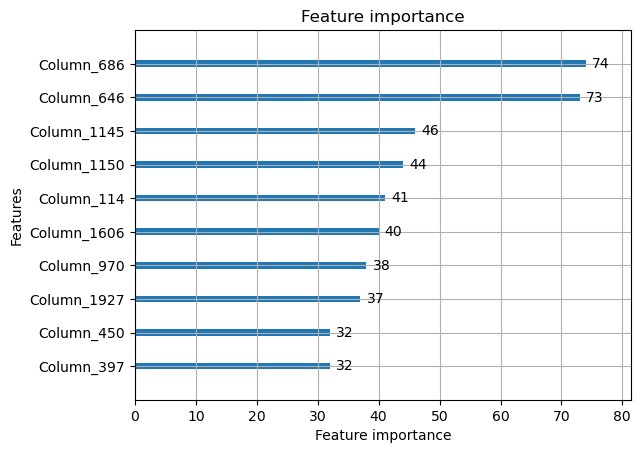

In [9]:
from lightgbm import plot_importance
# 显示重要特征
fig = plt.figure(figsize=(10,10))
plot_importance(clf,max_num_features=10)
plt.show()

In [10]:
T_pred = clf.predict(X_train)
confusion_matrix(T_train, T_pred)

array([[418,   9],
       [ 20, 364]])

In [11]:
print (classification_report(T_train, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.9543    0.9789    0.9665       427
           1     0.9759    0.9479    0.9617       384

    accuracy                         0.9642       811
   macro avg     0.9651    0.9634    0.9641       811
weighted avg     0.9645    0.9642    0.9642       811



In [12]:
# 十倍交叉验证

In [13]:
import sklearn.neural_network as cross_validate
clf=lgbm.LGBMClassifier(boosting_type='gbdt',colsample_bytree=0.8,feature_fraction=0.8,bagging_fraction=0.1,num_leaves=10,min_child_samples=60,max_depth=-1,
                        learning_rate=0.01,n_estimators=300, n_jobs=1)

cv = 10  # 十倍交叉验证的折数
scoring = ['accuracy', 'precision_macro', 'f1_macro']  # 评估指标


In [15]:
scores = cross_validate(clf, X_train, T_train, cv=cv, scoring=scoring, return_train_score=True)

mean_accuracy = scores['test_accuracy'].mean()
mean_precision = scores['test_precision_macro'].mean()
mean_f1 = scores['test_f1_macro'].mean()

std_accuracy = scores['test_accuracy'].std()
std_precision = scores['test_precision_macro'].std()
std_f1 = scores['test_f1_macro'].std()

mean_train_accuracy = scores['train_accuracy'].mean()
mean_train_precision = scores['train_precision_macro'].mean()
mean_train_f1 = scores['train_f1_macro'].mean()

std_train_accuracy = scores['train_accuracy'].std()
std_train_precision = scores['train_precision_macro'].std()
std_train_f1 = scores['train_f1_macro'].std()

print(f'Mean Accuracy (Test): {mean_accuracy:.4f} ± {std_accuracy:.4f}')
print(f'Mean Precision (Test): {mean_precision:.4f} ± {std_precision:.4f}')
print(f'Mean F1 Score (Test): {mean_f1:.4f} ± {std_f1:.4f}')

print(f'Mean Accuracy (Train): {mean_train_accuracy:.4f} ± {std_train_accuracy:.4f}')
print(f'Mean Precision (Train): {mean_train_precision:.4f} ± {std_train_precision:.4f}')
print(f'Mean F1 Score (Train): {mean_train_f1:.4f} ± {std_train_f1:.4f}')


TypeError: 'module' object is not callable

In [16]:
from sklearn.linear_model import LogisticRegression
clf =  LogisticRegression(solver='liblinear',multi_class='ovr', C = 0.1, verbose =0, max_iter=100)
clf.fit(X_train, T_train)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=0.1, multi_class='ovr', solver='liblinear')

In [17]:
import pandas as pd
import numpy as np
import time
import logging
import os, sys
import psutil
import lightgbm as lgb
from datetime import datetime

from itertools import cycle
from sklearn import svm
from sklearn.metrics import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

from scipy import interp

T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[87,  8],
       [16, 92]])

In [18]:
precision_score(T_test, T_pred,average='micro')
recall_score(T_test, T_pred,average='micro')
f1_score(T_test, T_pred,average='micro')

0.8817733990147785

In [19]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.8447    0.9158    0.8788        95
           1     0.9200    0.8519    0.8846       108

    accuracy                         0.8818       203
   macro avg     0.8823    0.8838    0.8817       203
weighted avg     0.8847    0.8818    0.8819       203



In [20]:
T_pred = clf.predict(X_train)
confusion_matrix(T_train, T_pred)

array([[423,   4],
       [  9, 375]])

In [21]:
print (classification_report(T_train, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.9792    0.9906    0.9849       427
           1     0.9894    0.9766    0.9830       384

    accuracy                         0.9840       811
   macro avg     0.9843    0.9836    0.9839       811
weighted avg     0.9840    0.9840    0.9840       811



In [22]:
import sklearn.neural_network as sk_nn
clf = sk_nn.MLPClassifier(activation='logistic',solver='adam',alpha=1,learning_rate='adaptive',learning_rate_init=0.0001,max_iter=500)
clf.fit(X_train,T_train)


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1109: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(activation='logistic', alpha=1, learning_rate='adaptive',
              learning_rate_init=0.0001, max_iter=500)

In [23]:
T_pred = clf.predict(X_train)
confusion_matrix(T_train, T_pred)

array([[420,   7],
       [ 21, 363]])

In [24]:
T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[85, 10],
       [19, 89]])

In [25]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.8173    0.8947    0.8543        95
           1     0.8990    0.8241    0.8599       108

    accuracy                         0.8571       203
   macro avg     0.8581    0.8594    0.8571       203
weighted avg     0.8608    0.8571    0.8573       203



In [26]:
import sklearn.neighbors as sk_neighbors
clf = sk_neighbors.KNeighborsClassifier(n_neighbors=4) 
clf.fit(X_train,T_train)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=4)

In [27]:
T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


array([[88,  7],
       [11, 97]])

In [28]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.8889    0.9263    0.9072        95
           1     0.9327    0.8981    0.9151       108

    accuracy                         0.9113       203
   macro avg     0.9108    0.9122    0.9112       203
weighted avg     0.9122    0.9113    0.9114       203



In [29]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier (
bootstrap=True, max_depth=None,
max_features='auto', max_leaf_nodes=None,
min_impurity_decrease=0.0,
min_samples_leaf=1, min_samples_split=10,
min_weight_fraction_leaf=0.0, n_estimators=300, n_jobs=2,
oob_score=False, random_state=725, verbose=0, warm_start=False)
clf.fit(X_train,T_train) # 使用训练集训练模型
T_pre = clf.predict(X_test) # 使用模型对测试集进行预测

/tmp/ipykernel_50493/987808909.py:9: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  clf.fit(X_train,T_train) # 使用训练集训练模型


In [30]:
T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[88,  7],
       [15, 93]])

In [31]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.8544    0.9263    0.8889        95
           1     0.9300    0.8611    0.8942       108

    accuracy                         0.8916       203
   macro avg     0.8922    0.8937    0.8916       203
weighted avg     0.8946    0.8916    0.8917       203



In [32]:
from sklearn.tree import DecisionTreeClassifier
 
clf = DecisionTreeClassifier(                         splitter="best",
                         max_depth=None,
                         min_samples_split=2,
                         min_samples_leaf=16,
                         min_weight_fraction_leaf=0.0,
                         max_features=4,
                         random_state=2,
                         max_leaf_nodes=None,
                         min_impurity_decrease=0)
 # 所以参数均置为默认状态
clf.fit(X_train,T_train) # 使用训练集训练模型
T_pre = clf.predict(X_test) # 使用模型对测试集进行预测

In [33]:
from sklearn.metrics import accuracy_score
 
print (accuracy_score(T_pre, T_test))

0.7339901477832512


In [34]:
T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[74, 21],
       [33, 75]])

In [35]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.6916    0.7789    0.7327        95
           1     0.7812    0.6944    0.7353       108

    accuracy                         0.7340       203
   macro avg     0.7364    0.7367    0.7340       203
weighted avg     0.7393    0.7340    0.7341       203

